# rf_code

Random Forest combina árboles de decisión y puede capturar relaciones no lineales. Permite comprobar si las interacciones entre clima, movilidad, búsquedas, calendario y retardos aportan valor predictivo. Con una historia mensual corta, esta flexibilidad puede aumentar la varianza y el sobreajuste.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip -q install scikit-learn matplotlib pandas numpy


>> Ejecutando Optimización (Random + Grid Search)...
Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 300}


--- RENDIMIENTO DEL MODELO ---
MAE (Error Absoluto Medio): 246,901 pernoctaciones/mes
RMSE (Raíz del Error Cuadrático Medio): 282,402
MAPE: 8.21%
R2:   0.8674



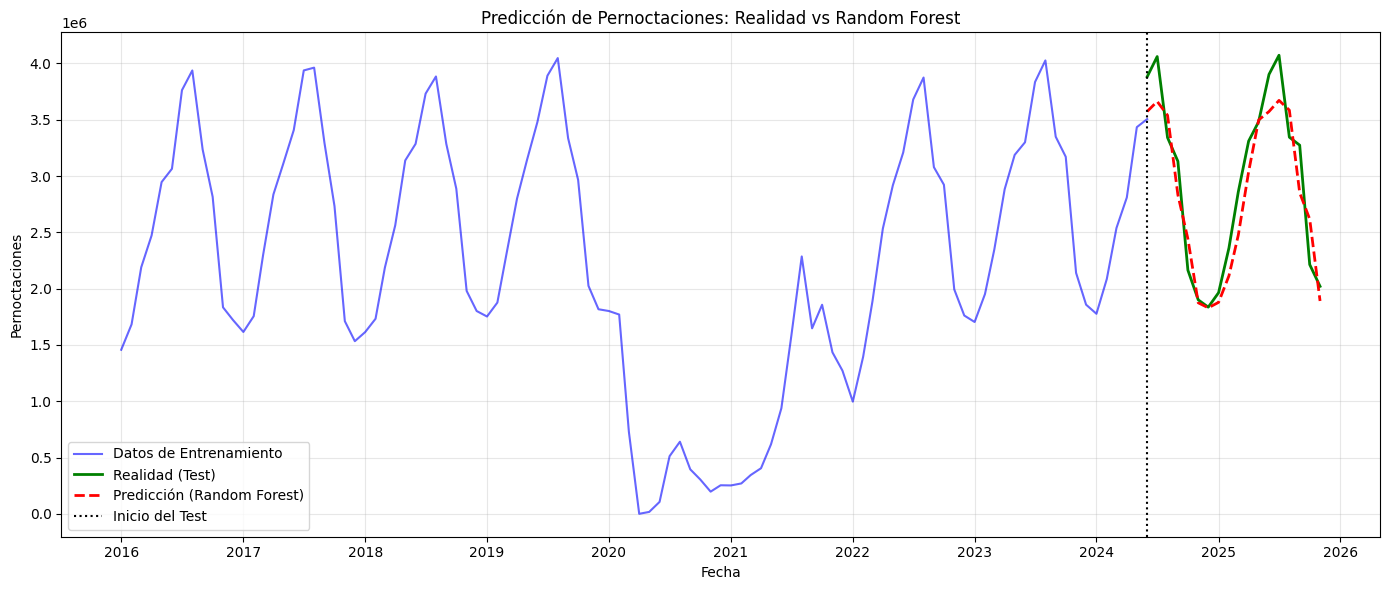

 PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)
Umbral Verde/Naranja: 1,834,345 pernoctaciones
Umbral Naranja/Rojo:  3,018,909 pernoctaciones
Aciertos de nivel de alerta: 83.3% (15/18 meses)

fecha_objetivo  pernoctaciones_real  pernoctaciones_predicha ipt_real  codigo_real ipt_predicho  codigo_predicho  acierto_nivel
    2024-06-01            3881922.0             3.573606e+06     Rojo            2         Rojo                2           True
    2024-07-01            4061207.0             3.662461e+06     Rojo            2         Rojo                2           True
    2024-08-01            3341674.0             3.539705e+06     Rojo            2         Rojo                2           True
    2024-09-01            3130930.0             2.833634e+06     Rojo            2      Naranja                1          False
    2024-10-01            2164179.0             2.442250e+06  Naranja            1      Naranja                1           True
    2024-11-01            1900241.0       

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. CARGA DE DATOS
RUTA_DATOS = "/content/drive/MyDrive/VIU/TFM/Data/DATASET_TFM_FINAL.csv"
TARGET = "Pernoctaciones"
HORIZONTE = 1     # meses de antelación
MESES_TEST = 18   # ventana de test

df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"], index_col="fecha")
df = df.sort_index()
y_abs = df[TARGET]


# Safe features
df["pernoctaciones_lag_1"] = y_abs.shift(1)
df["pernoctaciones_lag_2"] = y_abs.shift(2)
df["pernoctaciones_lag_3"] = y_abs.shift(3)
df["pernoctaciones_roll_mean_3"] = y_abs.shift(1).rolling(3).mean()
df["pernoctaciones_roll_mean_12"] = y_abs.shift(1).rolling(12).mean()
df["pernoctaciones_roll_std_3"] = y_abs.shift(1).rolling(3).std()
df["pernoctaciones_ewm_12"] = y_abs.shift(1).ewm(span=12, adjust=False).mean()
df["yoy_growth_lag1"] = y_abs.pct_change(12).shift(1).replace([np.inf, -np.inf], np.nan)
df["pernoctaciones_diff_lag_1"] = y_abs.diff().shift(1)

SAFE_FEATURES = [
    "mes_sin", "mes_cos", "es_festivo", "es_fin_semana", "dia_libre_real", "es_covid",
    "pernoctaciones_lag_1", "pernoctaciones_lag_2", "pernoctaciones_lag_3",
    "pernoctaciones_roll_mean_3", "pernoctaciones_roll_mean_12",
    "pernoctaciones_roll_std_3", "pernoctaciones_ewm_12", "yoy_growth_lag1",
    "pernoctaciones_diff_lag_1",
    "llegadas_lag_1", "llegadas_lag_2",
    "barcelona flights_lag_1", "barcelona flights_lag_2",
    "barcelona hotel_lag_1", "barcelona hotel_lag_2",
    "airbnb barcelona_lag_1", "airbnb barcelona_lag_2",
]


def build_dataset_diff(data, h, features, target=TARGET):
    """X (features seguras en t) e y_diff = valor absoluto(t+h) - valor absoluto(t).
    El shift(-h) se calcula ANTES del dropna para no desalinear las fechas."""
    d = data.copy()
    d["y_abs_objetivo"] = d[target].shift(-h)
    d["y_diff_h"] = d["y_abs_objetivo"] - d[target]
    d = d.dropna(subset=features + ["y_diff_h"])
    X = d[features]
    y_diff = d["y_diff_h"]
    y_abs_ancla = d[target]
    y_abs_objetivo = d["y_abs_objetivo"]
    return X, y_diff, y_abs_ancla, y_abs_objetivo


X, y_diff, y_abs_ancla, y_abs_obj = build_dataset_diff(df, HORIZONTE, SAFE_FEATURES)

X_train, X_test = X.iloc[:-MESES_TEST], X.iloc[-MESES_TEST:]
y_train_diff, y_test_diff = y_diff.iloc[:-MESES_TEST], y_diff.iloc[-MESES_TEST:]
y_test_abs = y_abs_obj.iloc[-MESES_TEST:]
y_ancla_test = y_abs_ancla.iloc[-MESES_TEST:]


# 2. DOBLE OPTIMIZACIÓN RANDOM FOREST
tscv = TimeSeriesSplit(n_splits=4)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

print(">> Ejecutando Optimización (Random + Grid Search)...")
espacio_rf_random = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.7, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=rf_base, param_distributions=espacio_rf_random,
    n_iter=20, cv=tscv, scoring="neg_mean_absolute_error",
    random_state=42, n_jobs=-1, verbose=0,
)
random_search.fit(X_train, y_train_diff)
mejores = random_search.best_params_

# FASE 2: Grid Search (afinado alrededor de min_samples_leaf/split)
espacio_rf_grid = {
    "n_estimators": [mejores["n_estimators"]],
    "max_depth": [mejores["max_depth"]],
    "min_samples_split": sorted(set([max(2, mejores["min_samples_split"] - 1),
                                       mejores["min_samples_split"],
                                       mejores["min_samples_split"] + 1])),
    "min_samples_leaf": sorted(set([max(1, mejores["min_samples_leaf"] - 1),
                                      mejores["min_samples_leaf"],
                                      mejores["min_samples_leaf"] + 1])),
    "max_features": [mejores["max_features"]],
}

grid_search = GridSearchCV(
    estimator=rf_base, param_grid=espacio_rf_grid, cv=tscv,
    scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0,
)
grid_search.fit(X_train, y_train_diff)
modelo_rf_opt = grid_search.best_estimator_

print(f"Mejores hiperparámetros: {grid_search.best_params_}\n")

# 3. PREDICCIÓN Y RECONSTRUCCIÓN MATEMÁTICA

predicciones_diff = pd.Series(modelo_rf_opt.predict(X_test), index=y_test_diff.index)
predicciones_abs = y_ancla_test + predicciones_diff

# 4. MÉTRICAS DE EVALUACIÓN FINAL (SOBRE VALORES ABSOLUTOS, HORIZONTE 1 MES)
mae = mean_absolute_error(y_test_abs, predicciones_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, predicciones_abs))
mape = np.mean(np.abs((y_test_abs - predicciones_abs) / y_test_abs)) * 100
r2 = r2_score(y_test_abs, predicciones_abs)

print(f"\n--- RENDIMIENTO DEL MODELO ---")
print(f"MAE (Error Absoluto Medio): {mae:,.0f} pernoctaciones/mes")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2:   {r2:.4f}\n")

# 5. VISUALIZACIÓN
plt.figure(figsize=(14, 6))
plt.plot(y_abs.iloc[:-MESES_TEST].index, y_abs.iloc[:-MESES_TEST], label='Datos de Entrenamiento', color='blue', alpha=0.6)
plt.plot(y_test_abs.index, y_test_abs, label='Realidad (Test)', color='green', linewidth=2)
plt.plot(predicciones_abs.index, predicciones_abs, label='Predicción (Random Forest)', color='red', linestyle='--', linewidth=2)
plt.axvline(x=y_test_abs.index[0], color='black', linestyle=':', label='Inicio del Test')
plt.title('Predicción de Pernoctaciones: Realidad vs Random Forest')
plt.xlabel('Fecha')
plt.ylabel('Pernoctaciones')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_h1_ipt_final.png", dpi=110)
plt.show()


# 6. ÍNDICE DE PRESIÓN TURÍSTICA (IPT) - 3 NIVELES DE ALERTA
# Verde   -> presión turística baja/moderada (nivel menos grave)
# Naranja -> presión turística alta (nivel intermedio)
# Rojo    -> presión turística muy alta / saturación (nivel más grave)
#
# Umbrales sobre terciles (P33/P66) del histórico completo de pernoctaciones,
# igual que en el pipeline XGBoost, para que ambos modelos sean comparables
# con el mismo criterio de clasificación.
UMBRAL_VERDE_NARANJA, UMBRAL_NARANJA_ROJO = np.percentile(y_abs, [33, 66])

NIVELES_IPT = {
    0: "Verde",
    1: "Naranja",
    2: "Rojo",
}


def clasificar_ipt(valor_pernoctaciones):
    """Devuelve (nivel_texto, codigo_numerico) donde 0=Verde (menos grave)
    y 2=Rojo (más grave)."""
    if valor_pernoctaciones < UMBRAL_VERDE_NARANJA:
        codigo = 0
    elif valor_pernoctaciones < UMBRAL_NARANJA_ROJO:
        codigo = 1
    else:
        codigo = 2
    return NIVELES_IPT[codigo], codigo



# 6.1 Alertas IPT sobre todo el conjunto de test
alertas_test = pd.DataFrame({
    "fecha_objetivo": y_test_abs.index,
    "pernoctaciones_real": y_test_abs.values,
    "pernoctaciones_predicha": predicciones_abs.values,
})
alertas_test[["ipt_real", "codigo_real"]] = alertas_test["pernoctaciones_real"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test[["ipt_predicho", "codigo_predicho"]] = alertas_test["pernoctaciones_predicha"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test["acierto_nivel"] = alertas_test["codigo_real"] == alertas_test["codigo_predicho"]

precision_semaforo = alertas_test["acierto_nivel"].mean() * 100
print("=" * 45)
print(" PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)")
print("=" * 45)
print(f"Umbral Verde/Naranja: {UMBRAL_VERDE_NARANJA:,.0f} pernoctaciones")
print(f"Umbral Naranja/Rojo:  {UMBRAL_NARANJA_ROJO:,.0f} pernoctaciones")
print(f"Aciertos de nivel de alerta: {precision_semaforo:.1f}% ({alertas_test['acierto_nivel'].sum()}/{len(alertas_test)} meses)\n")
print(alertas_test.to_string(index=False))


# 6.2 Matriz de confusión simple entre niveles
matriz_confusion = pd.crosstab(
    alertas_test["ipt_real"], alertas_test["ipt_predicho"],
    rownames=["Real"], colnames=["Predicho"]
).reindex(index=["Verde", "Naranja", "Rojo"], columns=["Verde", "Naranja", "Rojo"], fill_value=0)
print("\nMatriz de confusión (niveles IPT):")
print(matriz_confusion)


# 6.3 Importancia de variables (propia de Random Forest, no disponible
#     de forma nativa en XGBoost con esta misma interpretación directa)
importancias = pd.Series(modelo_rf_opt.feature_importances_, index=SAFE_FEATURES).sort_values(ascending=False)
print("\nImportancia de variables (Random Forest, top 10):")
print(importancias.head(10).to_string())

# 7. EXPORTAR RESULTADOS
resumen_metrico = pd.DataFrame([{
    "Horizonte (meses)": HORIZONTE,
    "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2,
    "Precision_semaforo (%)": precision_semaforo,
}])
resumen_metrico.to_csv("resultados_rf_ipt_h1.csv", index=False)
alertas_test.to_csv("alertas_ipt_h1_test_rf.csv", index=False)
matriz_confusion.to_csv("matriz_confusion_ipt_h1_rf.csv")
importancias.to_csv("importancia_variables_rf_h1.csv", header=["importancia"])

print("\nArchivos exportados: resultados_rf_ipt_h1.csv, alertas_ipt_h1_test_rf.csv, "
      "matriz_confusion_ipt_h1_rf.csv, importancia_variables_rf_h1.csv, rf_h1_ipt_final.png")
